In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import load_posterior, plot_mr, plot_ml, plot_pressure, plot_pop, corner_plot, get_quantiles, r14_confidence_interval, l14_confidence_interval, mtov_confidence_interval, plot_mr_nofill, plot_pop_nofill

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../eos/RMF3_cold_beta_lamb.d", unpack=True, usecols=[1,3])

latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"

def confidence_interval(samples, weights):

    lower, median, upper = np.quantile(samples, [0.025, 0.5, 0.975], weights=weights, method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.2f}}}_{{-{minus:.2f}}}^{{+{plus:.2f}}}"

## narrow ETL

In [3]:
directory = Path("../narrow_ETL")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
posterior_mm_alt = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm_mid" / "results.h5")
posterior_mm_full = load_posterior(directory / "inference_eos" / "mm_full" / "outdir_mm" / "results.h5")
posterior_mm_cheat = load_posterior(directory / "inference_eos" / "mm_cheating" / "outdir_mm" / "results.h5")
posterior_gw_source_frame = load_posterior(directory / "inference_eos" / "gw_with_source_frame" / "outdir_gw" / "results.h5")



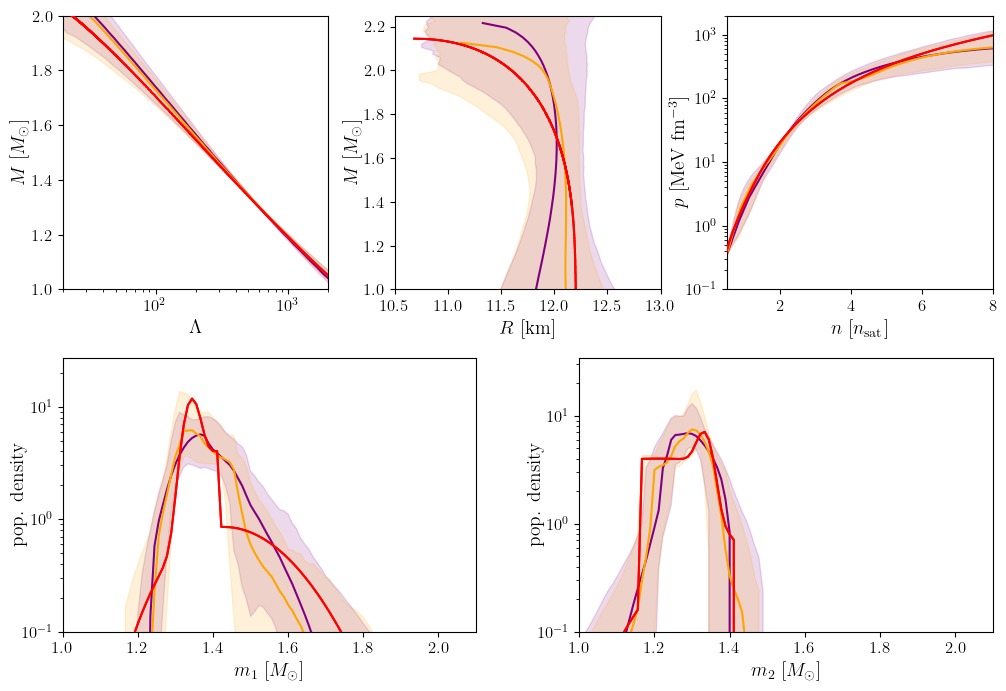

In [23]:
fig = plt.figure(figsize=(12, 8))

outer = fig.add_gridspec(2, 1, hspace=0.25)

# upper: 3 side to side panels
upper = outer[0].subgridspec(1, 3, wspace=0.25)

# lower: 2 side to side panels
lower = outer[1].subgridspec(1, 2, wspace=0.25)

ax_ml= fig.add_subplot(upper[0])
ax_mr = fig.add_subplot(upper[1])
ax_pressure = fig.add_subplot(upper[2])
ax_pop1 = fig.add_subplot(lower[0])
ax_pop2 = fig.add_subplot(lower[1])

plot_ml(ax_ml, posterior_gw, color="purple")
plot_ml(ax_ml, posterior_mm, color="orange")

plot_mr(ax_mr, posterior_gw, color="purple", plot_bestfit=True)
plot_mr(ax_mr, posterior_mm, color="orange", plot_bestfit=True)

plot_pressure(ax_pressure, posterior_gw, color="purple", plot_bestfit=True)
plot_pressure(ax_pressure, posterior_mm, color="orange",)

plot_pop([ax_pop1, ax_pop2], posterior_gw, color="purple")
plot_pop([ax_pop1, ax_pop2], posterior_mm, color="orange")

fig.savefig(
    "../../figures/eos_inference_narrow_ETL.pdf",
    dpi=250,
    bbox_inches="tight"
)

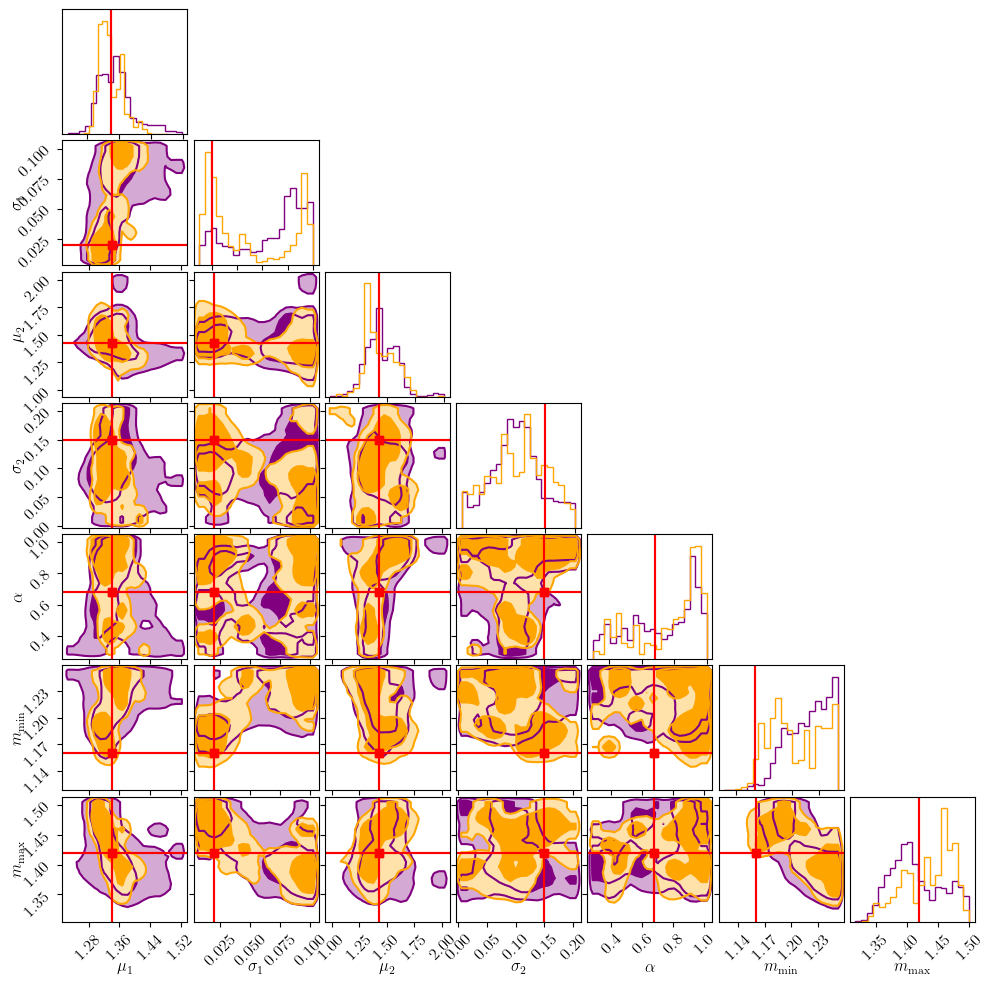

In [30]:
fig = corner_plot(posterior_gw, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["mu_1", "sigma_1", "mu_2", "sigma_2", "alpha", "m_min", "m_max"], fig, color="orange")

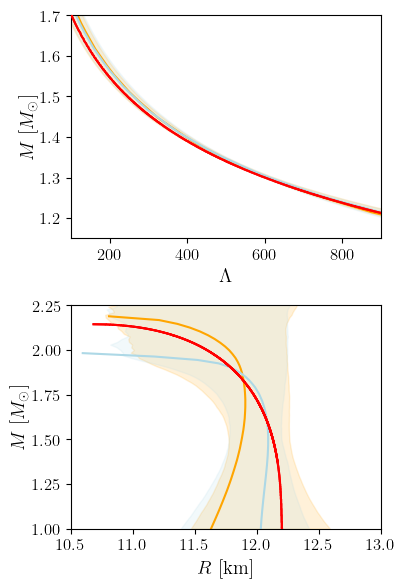

In [60]:
fig, ax = plt.subplots(2, 1, figsize=(4, 10*2/3))
fig.subplots_adjust(hspace=0.3)

posterior_mm["weights"] = np.full(7000, 1/7000)
posterior_mm_alt["weights"] = np.full(7000, 1/7000)

plot_ml(ax[0], posterior_mm, color="orange")
plot_ml(ax[0], posterior_mm_alt, color="lightblue")

ax[0].set_ylim((1.15, 1.7))
ax[0].set_xlim((100, 900))
ax[0].set_xscale("linear")


plot_mr(ax[1], posterior_mm, color="orange")
plot_mr(ax[1], posterior_mm_alt, color="lightblue")

fig.savefig("../../figures/eos_inference_narrow_ETL_mm_vs_gw.pdf", dpi=250, bbox_inches="tight")

In [4]:
print(l14_confidence_interval(posterior_mm))
print(l14_confidence_interval(posterior_gw))


{392}^{+15}_{-14}
{393}^{+16}_{-19}


In [32]:
print(confidence_interval(posterior_gw["mu_2"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["mu_2"], posterior_mm["weights"]))

{1.44}_{-0.22}^{+0.27}
{1.41}_{-0.19}^{+0.27}


(0.0, 0.2)

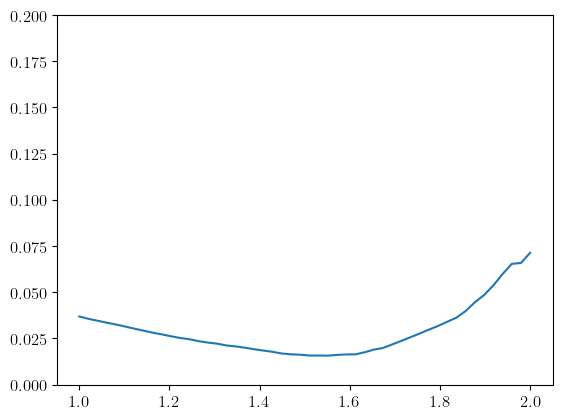

In [14]:
xs, quantiles, _ = get_quantiles(np.linspace(1, 2, 50), posterior_gw["masses_EOS"], posterior_gw["radii_EOS"], posterior_gw["weights"])
plt.plot(xs, (quantiles[:, 2] / quantiles[:, 0] - 1))
plt.ylim((0, 0.2))

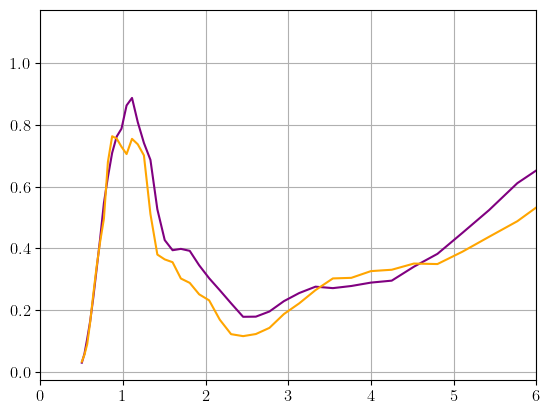

In [25]:
xs, quantiles, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_gw["densities_EOS"]/0.16, posterior_gw["pressures_EOS"], posterior_gw["weights"])
xs, quantiles_mm, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_mm["densities_EOS"]/0.16, posterior_mm["pressures_EOS"], posterior_mm["weights"])

plt.plot(xs, (quantiles[:, 2] / quantiles[:, 0])-1, color="purple")
plt.plot(xs, (quantiles_mm[:, 2] / quantiles_mm[:, 0])-1, color="orange")
plt.xlim((0, 6))
plt.grid(True)

In [ ]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.01}^{+0.29}_{-0.22}
{11.98}^{+0.27}_{-0.23}


In [6]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{393.32}^{+15.88}_{-18.94}
{392.08}^{+15.40}_{-14.28}


In [26]:
print(mtov_confidence_interval(posterior_gw))
print(mtov_confidence_interval(posterior_mm))

{2.15}^{+0.27}_{-0.19}
{2.12}^{+0.23}_{-0.17}


In [27]:
print(pressure_confidence_interval(posterior_gw))
print(pressure_confidence_interval(posterior_mm))

{83}^{+34}_{-16}
{77}^{+25}_{-13}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


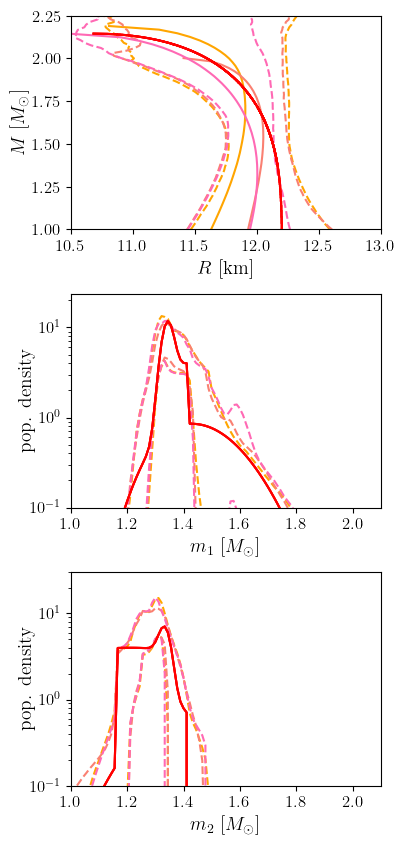

In [5]:
posterior_mm_cheat["weights"] = np.full((7000, ), 1/7000)
posterior_mm["weights"] = np.full((7000, ), 1/7000)
posterior_mm_full['weights'] = np.full((7000, ), 1/7000)

fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr_nofill(ax[0], posterior_mm, color="orange")
plot_mr_nofill(ax[0], posterior_mm_full, color="salmon")
plot_mr_nofill(ax[0], posterior_mm_cheat, color="hotpink")

plot_pop_nofill(ax[1:], posterior_mm, color="orange")
plot_pop_nofill(ax[1:], posterior_mm_full, color="salmon")
plot_pop_nofill(ax[1:], posterior_mm_cheat, color="hotpink")

fig.savefig("../../figures/eos_inference_different_mm.pdf", dpi=250, bbox_inches="tight")


In [6]:
print(l14_confidence_interval(posterior_mm))
print(l14_confidence_interval(posterior_mm_alt))
print(l14_confidence_interval(posterior_mm_cheat))

{393}^{+14}_{-16}
{394}^{+16}_{-16}
{393}^{+13}_{-14}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


(11.5, 13.0)

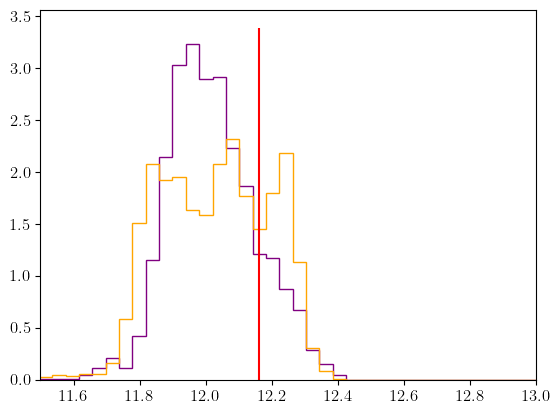

In [29]:
r14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])

bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim(11.5, 13.0)

(216.48202353105594, 427.737129027402)

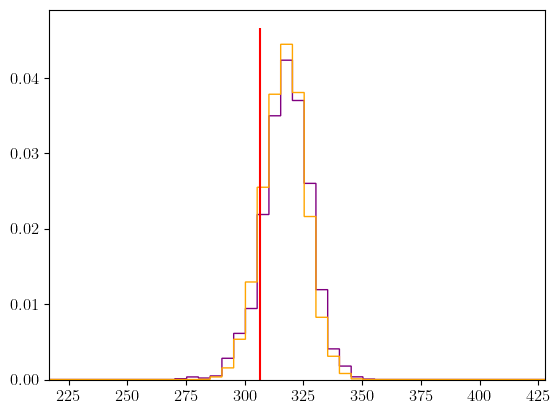

In [ ]:
l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])

bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_gw.min() * 0.8, l14_gw.max()*1.2))


## wide ETL

In [2]:
directory = Path("../wide_ETL")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")


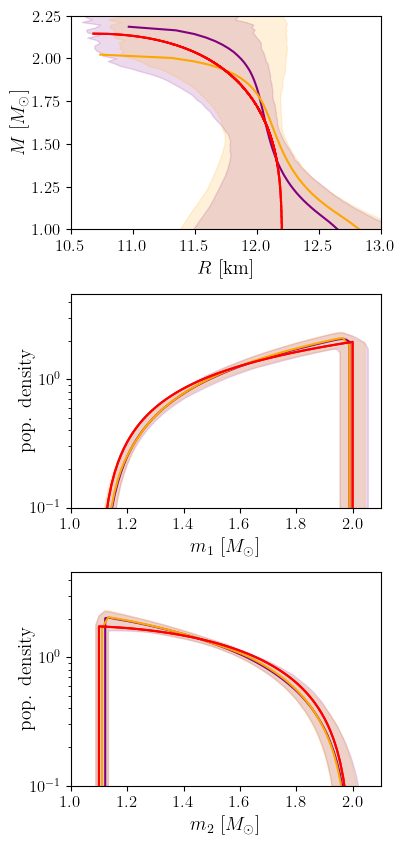

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_wide_ETL.pdf", dpi=250, bbox_inches="tight")

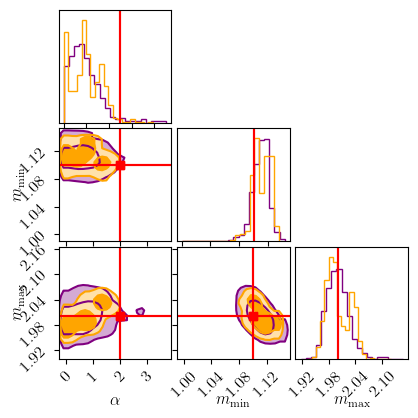

In [5]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

In [3]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{376}^{+20}_{-29}
{373}^{+21}_{-26}


/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [9]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.06}^{+0.26}_{-0.28}
{12.08}^{+0.25}_{-0.38}


In [10]:
print(pressure_confidence_interval(posterior_gw))
print(pressure_confidence_interval(posterior_mm))

{73}^{+27}_{-19}
{75}^{+38}_{-20}


(11.5, 13.0)

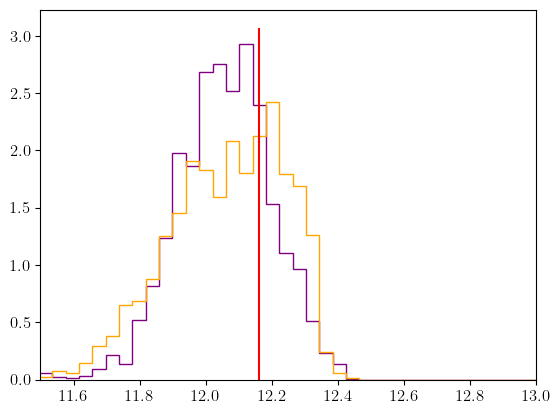

In [11]:
r14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])

bins = np.linspace(10, 14, 100)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])
plt.vlines([np.interp(1.4, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim(11.5, 13.0)

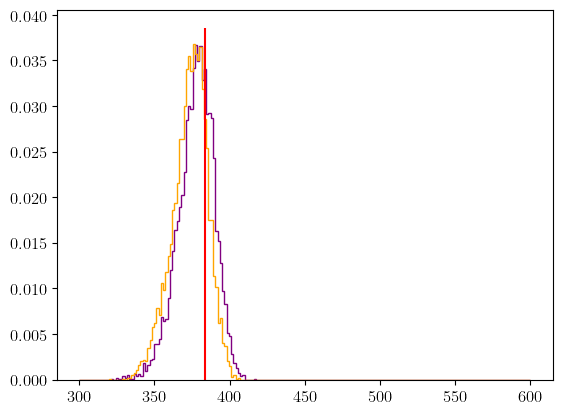

In [12]:
l14_gw = np.array([np.interp(1.4, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(1.4, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])

bins = np.linspace(300, 600, 200)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)
plt.vlines([np.interp(1.4, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")

In [13]:
print(confidence_interval(posterior_gw["alpha"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["alpha"], posterior_mm["weights"]))

{0.63}_{-0.58}^{+1.40}
{0.76}_{-0.74}^{+0.97}


# Narrow ETT

In [5]:
directory = Path("../narrow_ETT")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")


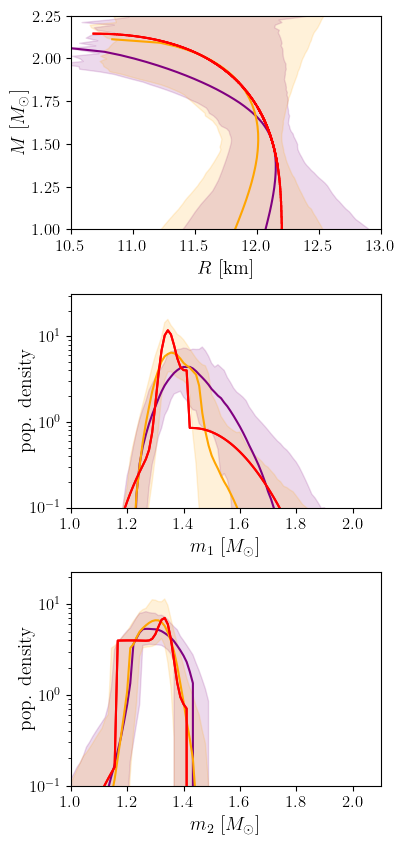

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)


plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_narrow_ETT.pdf", dpi=250, bbox_inches="tight")

In [6]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{404}^{+32}_{-37}
{400}^{+25}_{-26}


In [16]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.10}^{+0.28}_{-0.36}
{11.99}^{+0.25}_{-0.33}


(69.5246539675198, 265.5559390963009)

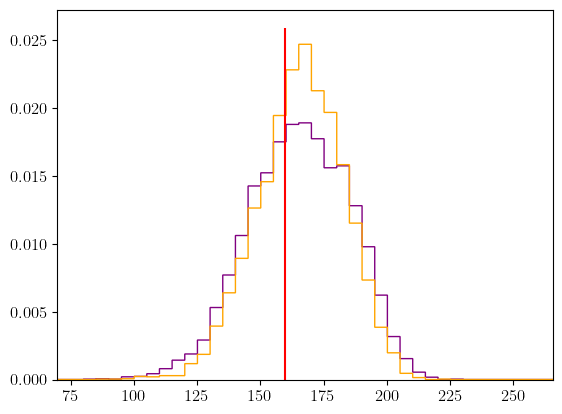

In [18]:
mx = 1.6

l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_mm.min()*0.8, l14_mm.max()*1.2))

## wide ETT

In [7]:
directory = Path("../wide_ETT")

posterior_gw = load_posterior(directory / "inference_eos" / "gw" / "outdir_gw" / "results.h5")
posterior_mm = load_posterior(directory / "inference_eos" / "mm" / "outdir_mm" / "results.h5")

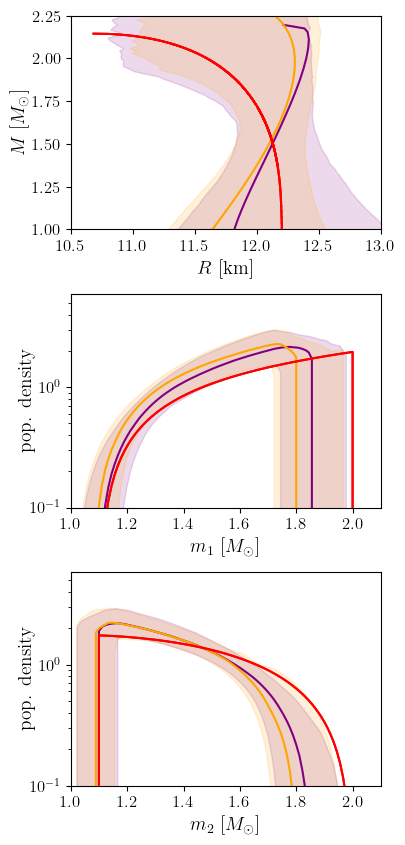

In [51]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")

plot_pop(ax[1:], posterior_gw, color="purple")
plot_pop(ax[1:], posterior_mm, color="orange")

fig.savefig("../../figures/eos_inference_wide_ETT.pdf", dpi=250, bbox_inches="tight")

In [8]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{426}^{+54}_{-47}
{428}^{+38}_{-42}


In [52]:
print(r14_confidence_interval(posterior_gw))
print(r14_confidence_interval(posterior_mm))

{12.16}^{+0.42}_{-0.38}
{12.14}^{+0.26}_{-0.39}


In [55]:
print(confidence_interval(posterior_gw["m_max"], posterior_gw["weights"]))
print(confidence_interval(posterior_mm["m_max"], posterior_mm["weights"]))

{1.86}_{-0.11}^{+0.13}
{1.81}_{-0.08}^{+0.17}


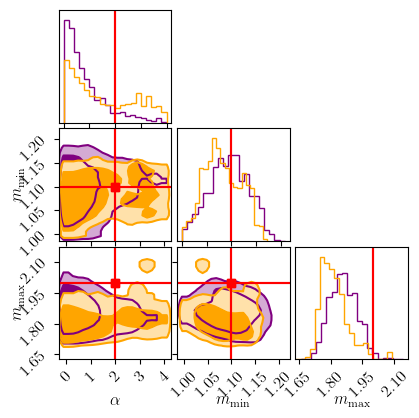

In [32]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

# compare wide_ETT and wide_ETL multi-messenger posterior

In [6]:
wide_ETL = load_posterior(Path("../wide_ETL") / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
wide_ETT = load_posterior(Path("../wide_ETT") / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
narrow_ETL = load_posterior(Path("../narrow_ETL") / "inference_eos" / "mm" / "outdir_mm" / "results.h5")
narrow_ETT = load_posterior(Path("../narrow_ETT") / "inference_eos" / "mm" / "outdir_mm" / "results.h5")

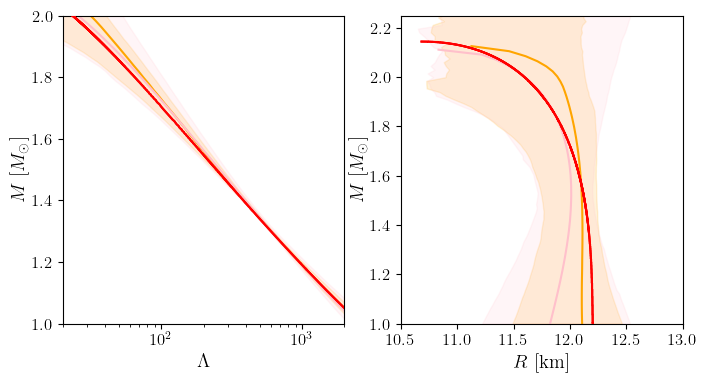

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

plot_ml(ax[0], narrow_ETL, color="orange")
plot_ml(ax[0], narrow_ETT, color="pink")
plot_mr(ax[1], narrow_ETL, color="orange")
plot_mr(ax[1], narrow_ETT, color="pink")